In [1]:
%run -i ../python_scripts/nb_setup.py

In [2]:
sgp_df = pickle.load(open("../experiments/CIFAR/sgp_set_cnn", "rb"))
print(sgp_df.shape)
sgp_df.head()

(40000, 3)


,y_true,y_pred,kappa
0,0.0,0.0,0.968736
1,0.0,1.0,0.870544
2,0.0,0.0,0.882295
3,0.0,0.0,0.768718
4,0.0,1.0,0.739913


In [3]:
sgp_df = sgp_df.iloc[: 3 * int(len(sgp_df) / 4)]  # train set
sgp_df = sgp_df.sort_values("kappa", ascending=True).reset_index(drop=True).copy()

In [4]:
delta = 0.005

### <font color = 'yellow'> Evolution of bounds with $\theta$

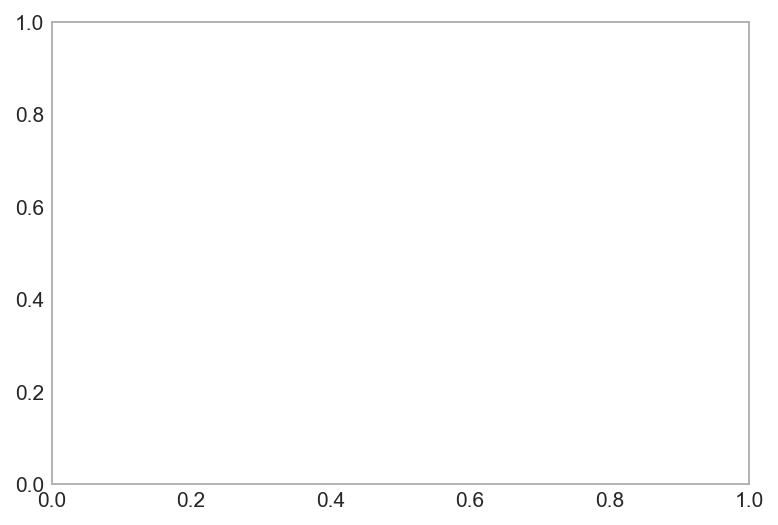

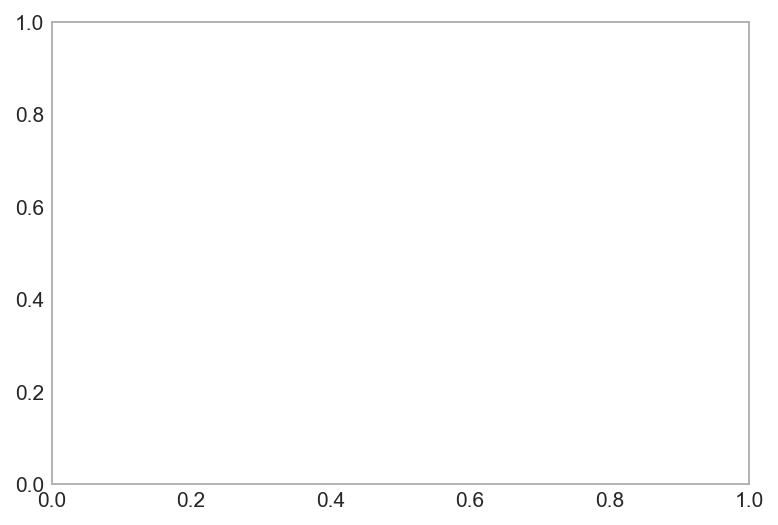

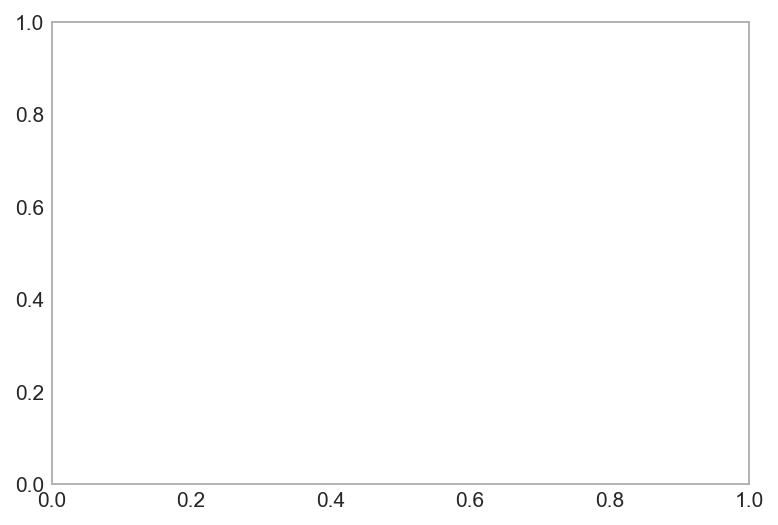

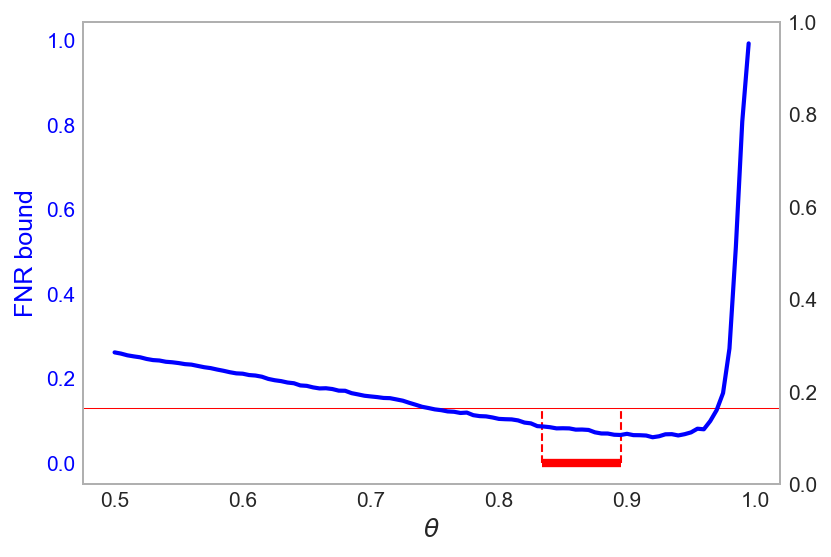

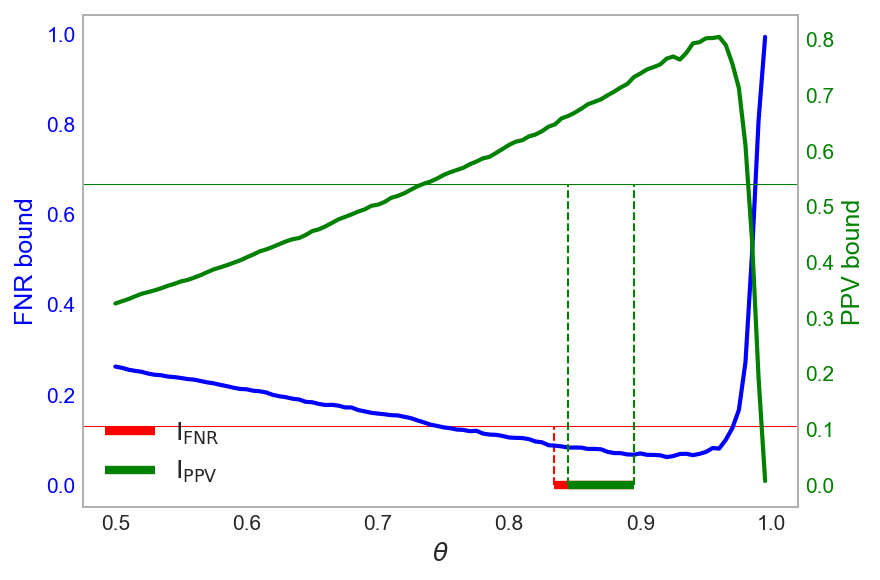

In [ ]:
# --- STYLE ONLY (doesn't change logic/data) -------------------------------------
rc = {
    "figure.figsize": (6, 4),
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.facecolor": "white",
    "legend.edgecolor": "#D0D0D0",
    "grid.alpha": 0.0,
}
with plt.rc_context(rc), plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax1 = plt.subplots()

    # make the primary axes look clean
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.9)
    ax1.xaxis.set_minor_locator(AutoMinorLocator())
    ax1.yaxis.set_minor_locator(AutoMinorLocator())

    # ---- ORIGINAL LOGIC (unchanged) -------------------------------------------
    # First y-axis (FNR)
    thetas, bounds = bound_evo_w_theta(
        "FNR",
        sgp_df,
        delta,
    )
    ax1.axhline(0.13, color="r", linewidth=0.5, zorder=1)
    ax1.vlines(0.834, 0, 0.13, colors="r", linewidth=1, linestyle="--", zorder=2)
    ax1.vlines(0.895, 0, 0.13, colors="r", linewidth=1, linestyle="--", zorder=2)
    theta_region_fnr = ax1.hlines(
        0,
        0.834,
        0.895,
        colors="r",
        linewidth=4,
        label=r"$\text{I}_{\text{FNR}}$",
        zorder=3,
    )
    ax1.plot(thetas, bounds, color="blue", linewidth=2, zorder=4)
    ax1.set_xlabel(r"$\theta$")
    ax1.set_ylabel("FNR bound", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")

    # Second y-axis (PPV)
    ax2 = ax1.twinx()
    # style the twin axis similarly
    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.9)
    ax2.yaxis.set_minor_locator(AutoMinorLocator())

    thetas, bounds = bound_evo_w_theta(
        "PPV",
        sgp_df,
        delta,
    )
    ax2.axhline(0.54, color="green", linewidth=0.5, zorder=1)
    ax2.vlines(0.845, 0, 0.54, colors="green", linewidth=1, linestyle="--", zorder=2)
    ax2.vlines(0.895, 0, 0.54, colors="green", linewidth=1, linestyle="--", zorder=2)
    theta_region_ppv = ax2.hlines(
        0,
        0.845,
        0.895,
        colors="green",
        linewidth=4,
        label=r"$\text{I}_{\text{PPV}}$",
        zorder=3,
    )
    ax2.plot(thetas, bounds, color="green", linewidth=2, zorder=4)
    ax2.set_ylabel("PPV bound", color="green")
    ax2.tick_params(axis="y", labelcolor="green")

    # Show legend
    ax1.legend(
        handles=[theta_region_fnr, theta_region_ppv], loc="lower left", fontsize=12
    )

    plt.tight_layout()
    plt.show()